# Optimization Rolling Analysis

This notebook analyzes the results from the Rolling Walk-Forward Optimization.
It focuses on:
1. Pareto Analysis (Identifying the "Vital Few")
2. Long vs. Short Performance Breakdown
3. Timeframe Comparison & Recommendations

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [11]:
df = pd.read_csv("optimization_rolling.csv")
print(f"Loaded {len(df)} rows.")
df.head()

Loaded 475 rows.


,Symbol,Timeframe,Fast_EMA,Slow_EMA,Train_PnL,Test_PnL,Trades,Win_Rate,Max_DD,Streak_W,Streak_L,Long_PnL,Short_PnL,Long_Trades,Short_Trades
0,DJ30,1m,Rolling,Rolling,0.0,-1551.06,1046,0.0,0.0,0,0,197.56,-1748.62,523,523
1,DJ30,5m,Rolling,Rolling,0.0,-5331.37,735,0.0,0.0,0,0,-675.01,-4656.36,369,366
2,DJ30,15m,Rolling,Rolling,0.0,-3706.89,269,0.0,0.0,0,0,96.78,-3803.67,135,134
3,DJ30,1h,Rolling,Rolling,0.0,-4849.57,118,0.0,0.0,0,0,-514.01,-4335.56,60,58
4,DJ30,4h,Rolling,Rolling,0.0,-3118.32,36,0.0,0.0,0,0,494.14,-3612.46,19,17


## 2. Results per Timeframe (Profitable Configs Only)
Which timeframes perform best when isolating only the winning strategies (Test_PnL > 0)?

In [12]:
# Filter for Positive PnL only
df_pos = df[df['Test_PnL'] > 0].copy()

# Aggregate Stats by Timeframe
tf_stats = df_pos.groupby('Timeframe')['Test_PnL'].agg(['sum', 'mean', 'count'])
tf_stats.columns = ['Total PnL', 'Avg PnL', 'Count']

# Calculate Win Rate (relative to the full dataset for that timeframe)
total_counts = df.groupby('Timeframe')['Test_PnL'].count()
tf_stats['Win Rate %'] = (tf_stats['Count'] / total_counts) * 100
tf_stats['Win Rate %'] = tf_stats['Win Rate %'].fillna(0)

# Sort by Total PnL
tf_stats = tf_stats.sort_values('Total PnL', ascending=False)
tf_stats.style.background_gradient(cmap='RdYlGn', subset=['Total PnL', 'Avg PnL', 'Win Rate %']).format("{:.2f}")

,Total PnL,Avg PnL,Count,Win Rate %
Timeframe,,,,
5m,44471.90,2340.63,19.00,20.00
1h,28421.92,980.07,29.00,30.53
15m,22028.88,957.78,23.00,24.21
4h,21767.99,621.94,35.00,36.84
1m,117.02,58.51,2.00,2.11


/tmp/ipykernel_55042/3576984997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tf_stats.index, y=tf_stats['Total PnL'], palette=colors)


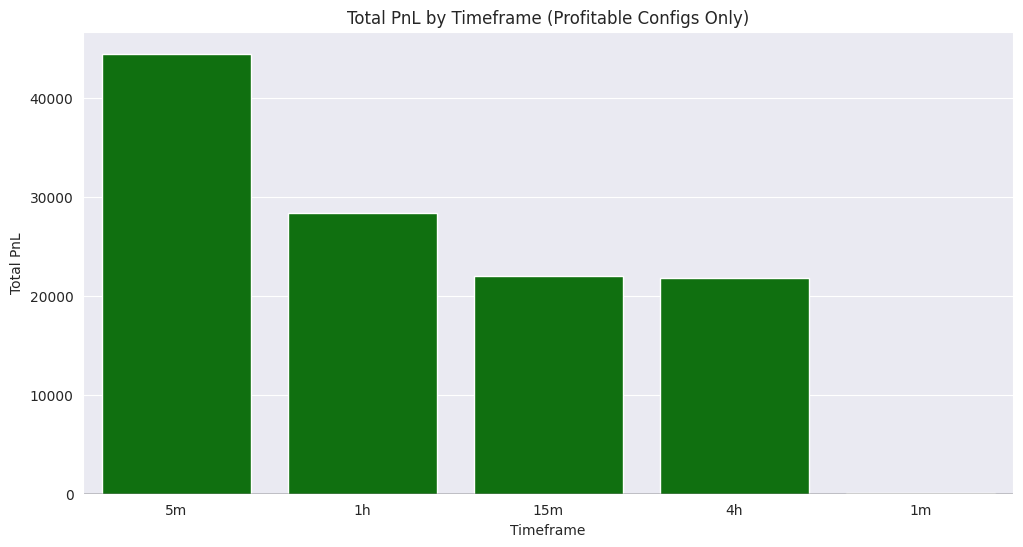

In [13]:
# Visualizing Timeframe Performance (Positive Configs)
plt.figure(figsize=(12, 6))
colors = ['green' for _ in tf_stats['Total PnL']]
sns.barplot(x=tf_stats.index, y=tf_stats['Total PnL'], palette=colors)
plt.title('Total PnL by Timeframe (Profitable Configs Only)')
plt.axhline(0, color='black', lw=1)
plt.show()

### Recommendation

In [14]:
print("RECOMMENDATION (Based on Profitable Configs):")
print("-" * 40)
print("Focus on timeframes that generate the highest cumulative profit from winning strategies.")
for tf, row in tf_stats.iterrows():
    print(f"⭐ {tf}: ${row['Total PnL']:.2f} (from {int(row['Count'])} winning configs)")
print("-" * 40)

RECOMMENDATION (Based on Profitable Configs):
----------------------------------------
Focus on timeframes that generate the highest cumulative profit from winning strategies.
⭐ 5m: $44471.90 (from 19 winning configs)
⭐ 1h: $28421.92 (from 29 winning configs)
⭐ 15m: $22028.88 (from 23 winning configs)
⭐ 4h: $21767.99 (from 35 winning configs)
⭐ 1m: $117.02 (from 2 winning configs)
----------------------------------------


## 3. Pareto Analysis (Profitable Configs Only)
Which configurations contribute the most to the total gross profit?

In [15]:
# Filter for profitable configs
profit_df = df[df['Test_PnL'] > 0].copy().sort_values('Test_PnL', ascending=False)

total_profit = profit_df['Test_PnL'].sum()
profit_df['Cum_PnL'] = profit_df['Test_PnL'].cumsum()
profit_df['Cum_Pct'] = profit_df['Cum_PnL'] / total_profit * 100

# Display Top 10 Contributors
cols = ['Symbol', 'Timeframe', 'Test_PnL', 'Cum_Pct', 'Long_PnL', 'Short_PnL']
profit_df[cols].head(15)

,Symbol,Timeframe,Test_PnL,Cum_Pct,Long_PnL,Short_PnL
131,BTCUSD,5m,27040.61,23.149679,-8071.88,35112.49
28,BVSPX,1h,18640.73,39.108155,25957.41,-7316.68
29,BVSPX,4h,13506.35,50.671047,24016.42,-10510.07
26,BVSPX,5m,9318.47,58.648663,22658.78,-13340.31
402,JPN225ft,15m,8504.18,65.929158,11626.80,-3122.62
132,BTCUSD,15m,4078.88,69.421120,-19111.61,23190.49
27,BVSPX,15m,3517.43,72.432419,19818.26,-16300.83
397,Nikkei225,15m,3436.20,75.374177,9061.47,-5625.27
399,Nikkei225,4h,3065.20,77.998319,9338.72,-6273.52
403,JPN225ft,1h,2361.12,80.019692,8545.32,-6184.20


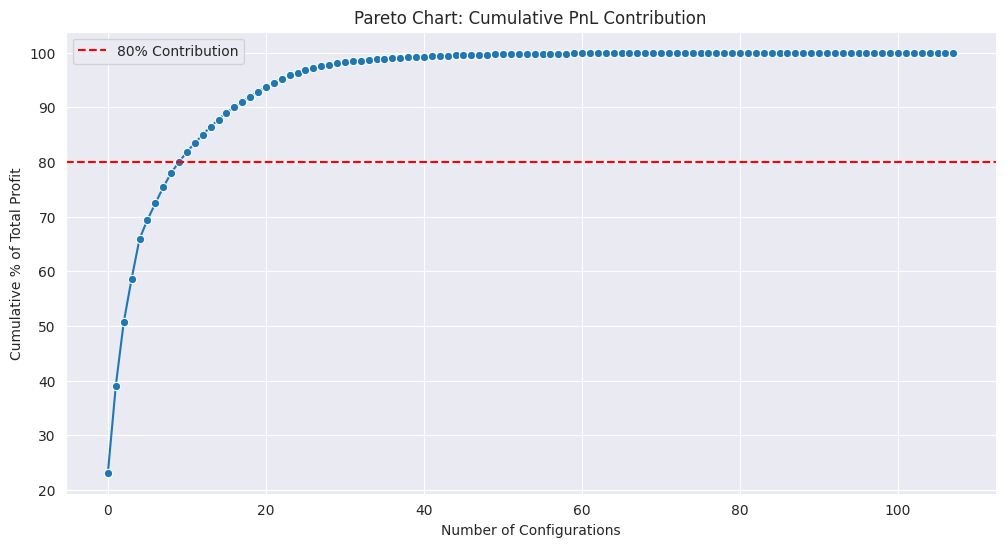

In [16]:
# Plot Pareto Curve
plt.figure(figsize=(12, 6))
sns.lineplot(data=profit_df.reset_index(), x=profit_df.reset_index().index, y='Cum_Pct', marker='o')
plt.axhline(80, color='red', linestyle='--', label='80% Contribution')
plt.title('Pareto Chart: Cumulative PnL Contribution')
plt.xlabel('Number of Configurations')
plt.ylabel('Cumulative % of Total Profit')
plt.legend()
plt.show()

## 4. Long vs Short Analysis
Do our best strategies profit more from Longs or Shorts?

In [ ]:
# Scatter Plot of Top 30 Performers
top_30 = profit_df.head(30)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_30, x='Long_PnL', y='Short_PnL', hue='Symbol', style='Timeframe', s=150)

# Reference lines
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# Diagonal line (Equal contribution)
limit = max(top_30['Long_PnL'].max(), top_30['Short_PnL'].max())
plt.plot([-limit, limit], [-limit, limit], color='gray', linestyle='--', alpha=0.5)

plt.title('Long PnL vs Short PnL (Top 30 Profitable Configs)')
plt.show()

In [ ]:
# Melt for Bar Chart Comparison
melted = top_30.melt(id_vars=['Symbol', 'Timeframe'], value_vars=['Long_PnL', 'Short_PnL'], var_name='Direction', value_name='PnL')
melted['Label'] = melted['Symbol'] + " (" + melted['Timeframe'] + ")"

plt.figure(figsize=(14, 8))
sns.barplot(data=melted, x='Label', y='PnL', hue='Direction', palette=['forestgreen', 'firebrick'])
plt.xticks(rotation=45, ha='right')
plt.title('Long vs Short PnL Breakdown (Top 15)')
plt.tight_layout()
plt.show()